In [86]:
# main file that works with Simulation.py

In [1]:
import cv2 as cv
import Simulation as S
from roi_config import rois
from scipy.optimize import least_squares
import numpy as np

In [2]:
import importlib
importlib.reload(S)

<module 'Simulation' from 'c:\\Users\\hallt3\\OneDrive - Rensselaer Polytechnic Institute\\Delay Line\\Inverse_Simulation\\Simulation.py'>

In [29]:


pairs = [
    ("images/Feb 9-1L.jpg", "images/Feb 9-1D.jpg"),
    ("images/Feb 9-2L.jpg", "images/Feb 9-2D.jpg"),
    ("images/N9L.jpg", "images/N9D.jpg")
]

frames = []
for light_path, dark_path in pairs:
    img_bgr = cv.imread(dark_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read dark image: {dark_path}")

    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    pts = S.reflec_pts_cam(gray, show=False)  # reflections from DARK
    K_by_mirror = {name: len(pts[name]) for name in rois.keys()}

    frames.append({
        "img_path_light": light_path,  # ArUco from LIGHT
        "img_path_dark": dark_path,    # just for record/debug
        "reflec_cam": pts,
        "K_by_mirror": K_by_mirror,
    })

print("Built frames:", len(frames))
print(frames[0]["img_path_light"], frames[0]["img_path_dark"])
print("K_by_mirror0:", frames[0]["K_by_mirror"])

Built frames: 3
images/Feb 9-1L.jpg images/Feb 9-1D.jpg
K_by_mirror0: {'M1': 2, 'M2': 2, 'M3': 2, 'M4': 1}


In [30]:
theta_guesses = [
    np.array([151.9551, 19.01, 167.91, 30.6566, 96.4861, 97.6544, 82.0039, 78.7591], float),
    np.array([151.9997, 18.9496, 167.9000, 30.6909, 96.7547, 97.8975, 82.3139, 79.4329], float),
    np.array([156.84147323, -0.71064846, 186.34250868, 32.52332345, 95.92301223, 95.95284302, 81.25699622, 79.90510536], float),
]

N = len(frames)
assert len(theta_guesses) == N, f"Need {N} theta guesses (one per image)."

thetas0 = np.vstack(theta_guesses)   # (N, 8)

In [31]:
M1y, M2y, M3y, M4y = 109, 75, 71, 117

In [ ]:
%%time
from scipy.optimize import least_squares

N = len(frames)

y_shared0 = np.array([M1y, M2y, M3y, M4y], float)

# thetas0 must already be (N,8)
p0 = S.pack_params(y_shared0, thetas0)

res = least_squares(
    fun=lambda p: S.residuals_bundle(p, frames),
    x0=p0,
    loss="huber",
    f_scale=1.0,
    verbose=2
)

p_hat = res.x
y_shared_hat, thetas_hat = S.unpack_params(p_hat, N)

print("y_shared_hat:", y_shared_hat)

for i, f in enumerate(frames):
    print(f"\nImage {i}: {f['img_path_light']}")
    print("theta_hat:", thetas_hat[i])

In [33]:
p_hat = res.x
N = len(frames)

# unpack bundle params
y_shared_hat, thetas_hat = S.unpack_params(p_hat, N)   # y_shared_hat shape (4,), thetas_hat shape (N,8)

print("\n===== SHARED Y (optimized) =====")
print(f"M1y, M2y, M3y, M4y = {y_shared_hat}")

print("\n===== THETA_HAT PER IMAGE =====")
for i, f in enumerate(frames):
    th = thetas_hat[i]
    print(f"\n[{i}] {f['img_path_light']}")
    print("theta_hat = [M1x M2x M3x M4x M1a M2a M3a M4a]")
    print(th)


===== SHARED Y (optimized) =====
M1y, M2y, M3y, M4y = [109.1254978   74.98038895  71.14772975 117.11700272]

===== THETA_HAT PER IMAGE =====

[0] images/Feb 9-1L.jpg
theta_hat = [M1x M2x M3x M4x M1a M2a M3a M4a]
[151.96003961  19.13102148 167.31655871  30.73746528  96.47960677
  97.68027957  82.0066747   78.7343315 ]

[1] images/Feb 9-2L.jpg
theta_hat = [M1x M2x M3x M4x M1a M2a M3a M4a]
[152.0015585   19.07402473 167.24206024  30.82588794  96.78629776
  98.01194432  82.38042656  79.42015703]

[2] images/N9L.jpg
theta_hat = [M1x M2x M3x M4x M1a M2a M3a M4a]
[157.72617116  -0.34944587 185.63282599  32.23597465  95.86615085
  95.94465206  81.43323314  80.01853758]


In [34]:
y_shared_hat, thetas_hat = S.unpack_params(res.x, len(frames))
M1y_hat, M2y_hat, M3y_hat, M4y_hat = y_shared_hat

# Make the sim functions use optimized y's (since they rely on globals)
S.M1y, S.M2y, S.M3y, S.M4y = M1y_hat, M2y_hat, M3y_hat, M4y_hat

In [35]:
print("Old Y:", S.M1y, S.M2y, S.M3y, S.M4y)
S.M1y, S.M2y, S.M3y, S.M4y = y_shared_hat
print("New Y:", S.M1y, S.M2y, S.M3y, S.M4y)

Old Y: 109.12549779520056 74.98038894565369 71.14772975145073 117.1170027227324
New Y: 109.12549779520056 74.98038894565369 71.14772975145073 117.1170027227324


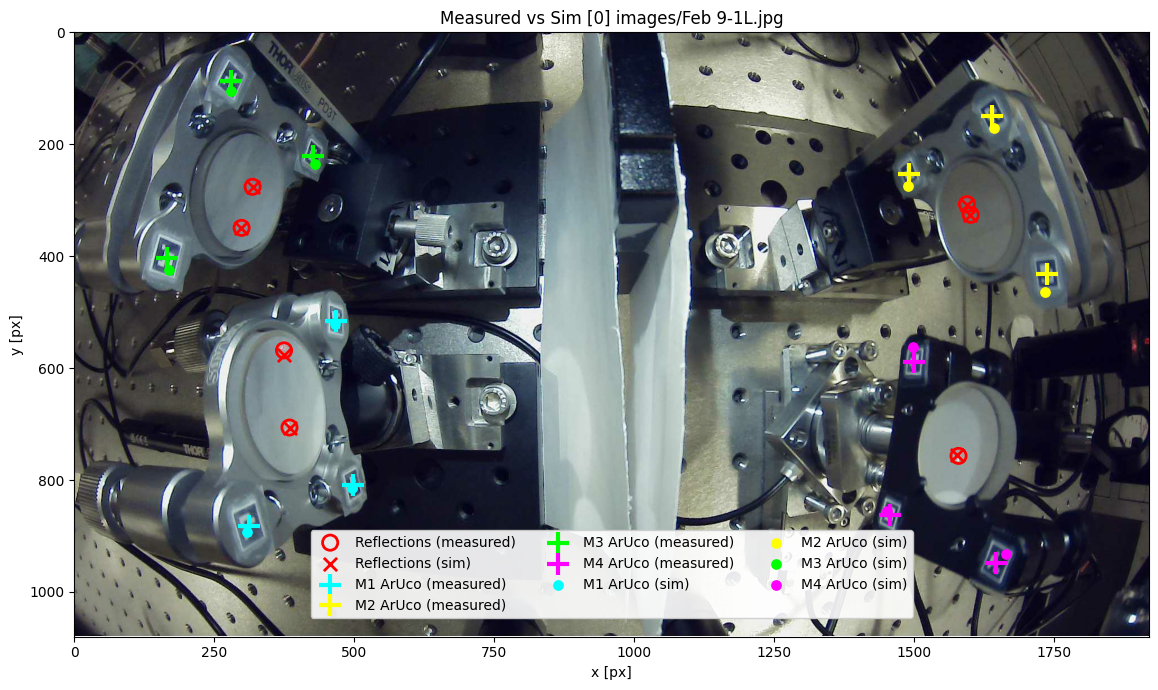

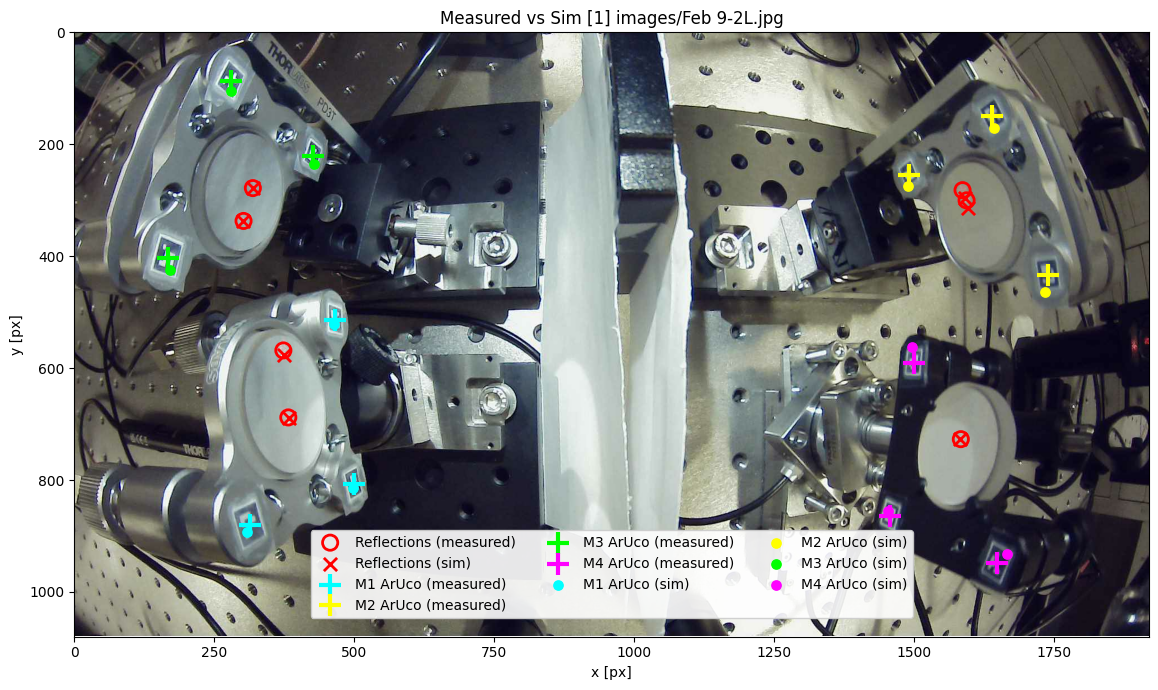

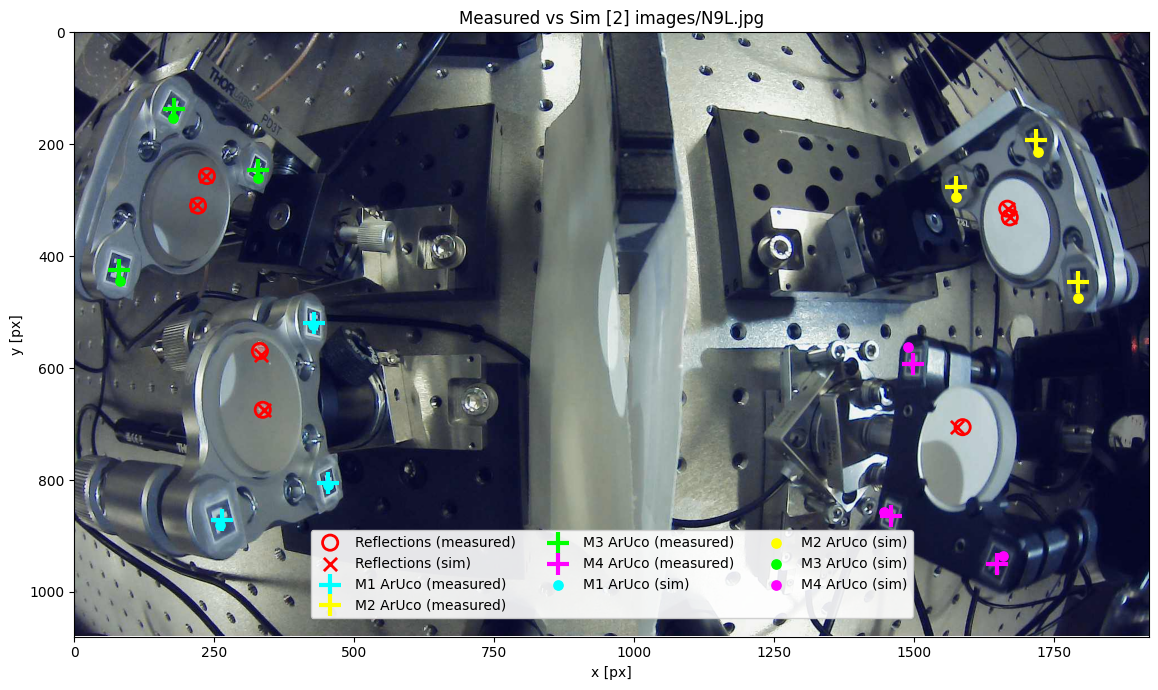

In [36]:


# after optimization
y_shared_hat, thetas_hat = S.unpack_params(res.x, len(frames))

# make sim functions use optimized shared y’s (they rely on globals)
S.M1y, S.M2y, S.M3y, S.M4y = y_shared_hat

for i, f in enumerate(frames):
    light_path = f["img_path_light"]
    dark_path  = f.get("img_path_dark", None)

    # --- load LIGHT image for overlay display ---
    img_light = cv.imread(light_path)
    if img_light is None:
        raise FileNotFoundError(light_path)

    # --- measured points ---
    # reflections: use what you computed from the DARK image for THIS frame
    refl_meas = f["reflec_cam"]  # dict M1..M4

    # arucos: detect from LIGHT image for THIS frame
    aruco_centers_12 = S.camera_arucos(light_path)  # list of 12
    aruco_meas = S.group_aruco_centers_by_mirror(aruco_centers_12)

    # --- per-image theta_hat ---
    th = thetas_hat[i]
    M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a = th

    # --- sim points (8 args ONLY) ---
    aruco_sim = S.sim_aruco_pts_by_mirror(M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a)
    refl_sim  = S.sim_reflection_pts_by_mirror(M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a)

    # --- overlay ---
    S.overlay_reflections_and_aruco(
        img_bgr=img_light,
        reflec_meas_by_mirror=refl_meas,
        aruco_meas_by_mirror=aruco_meas,
        reflec_sim_by_mirror=refl_sim,
        aruco_sim_by_mirror=aruco_sim,
        title=f"Measured vs Sim [{i}] {light_path}"
    )